# 실습 2-3 : 의사결정나무

#### **<실습 내용>**

1. 의사결정나무 회귀 (Regression)
- Day 2-1의 콘크리트 데이터를 사용하여 **선형 회귀와 성능 비교**
- 나무 시각화 및 max_depth에 따른 과적합 확인

2. 의사결정나무 분류 (Classification)
- Day 2-2의 제조 데이터를 사용하여 **로지스틱 회귀와 성능 비교**
- 나무 시각화 및 max_depth에 따른 과적합 확인
- 가지치기 (사전/사후)

3. 하이퍼 파라미터 최적화
- Grid Search를 통한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score)

## 1) 의사결정나무 회귀 (Regression)

> **의사결정나무(Decision Tree)** 는 입력변수 공간을 반복적으로 분할하여 예측 규칙을 나무 형태로 만드는 모델임
> - 분류와 회귀 모두에 사용할 수 있으며, 회귀 나무는 지니 불순도 대신 **분산(Variance)** 을 기준으로 노드를 분할함
> - 끝 노드에 속하는 학습 데이터들의 **평균값**을 예측값으로 사용함
> - Day 2-1에서 학습한 선형 회귀와 동일한 데이터로 성능을 비교함

### 1-1) 데이터 준비

> Day 2-1에서 사용한 콘크리트 압축강도 데이터를 동일하게 사용함

In [2]:
Concrete_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-3_reg_data.csv"))

In [3]:
# 입출력 변수 분할
Y_reg = Concrete_data["Concrete_compressive_strength"]
X_reg = Concrete_data.drop(["Concrete_compressive_strength"], axis=1)

# 학습/테스트 데이터 분할 (Day 2-1과 동일한 random_state 사용)
X_reg_train, X_reg_test, Y_reg_train, Y_reg_test = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 크기   :", X_reg_train.shape, Y_reg_train.shape)
print("테스트 데이터 크기 :", X_reg_test.shape, Y_reg_test.shape)

학습 데이터 크기   : (721, 8) (721,)
테스트 데이터 크기 : (309, 8) (309,)


In [4]:
# 회귀 모형 성능 지표 산출 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % (mean_squared_error(true, pred)))
    print("RMSE      : %.3f" % (np.sqrt(mean_squared_error(true, pred))))
    print("MAE       : %.3f" % (mean_absolute_error(true, pred)))
    print("R-squared : %.3f" % (r2_score(true, pred)))

### 1-2) 모델 학습

In [5]:
DT_reg1 = DecisionTreeRegressor()
DT_reg1.fit(X_reg_train, Y_reg_train)
DT_reg1_pred = DT_reg1.predict(X_reg_test)

print("=== 의사결정나무 회귀 ===")
get_regscore(Y_reg_test, DT_reg1_pred)
print()
print("=== Day 2-1 다중선형회귀 참고 성능 ===")
print("RMSE      : 9.676")
print("R-squared : 0.635")

=== 의사결정나무 회귀 ===
MSE       : 54.689
RMSE      : 7.395
MAE       : 4.708
R-squared : 0.787

=== Day 2-1 다중선형회귀 참고 성능 ===
RMSE      : 9.676
R-squared : 0.635


### 1-3) 나무 시각화

> 회귀 나무에서는 각 끝 노드의 **value**가 해당 영역 데이터의 평균 예측값을 의미함

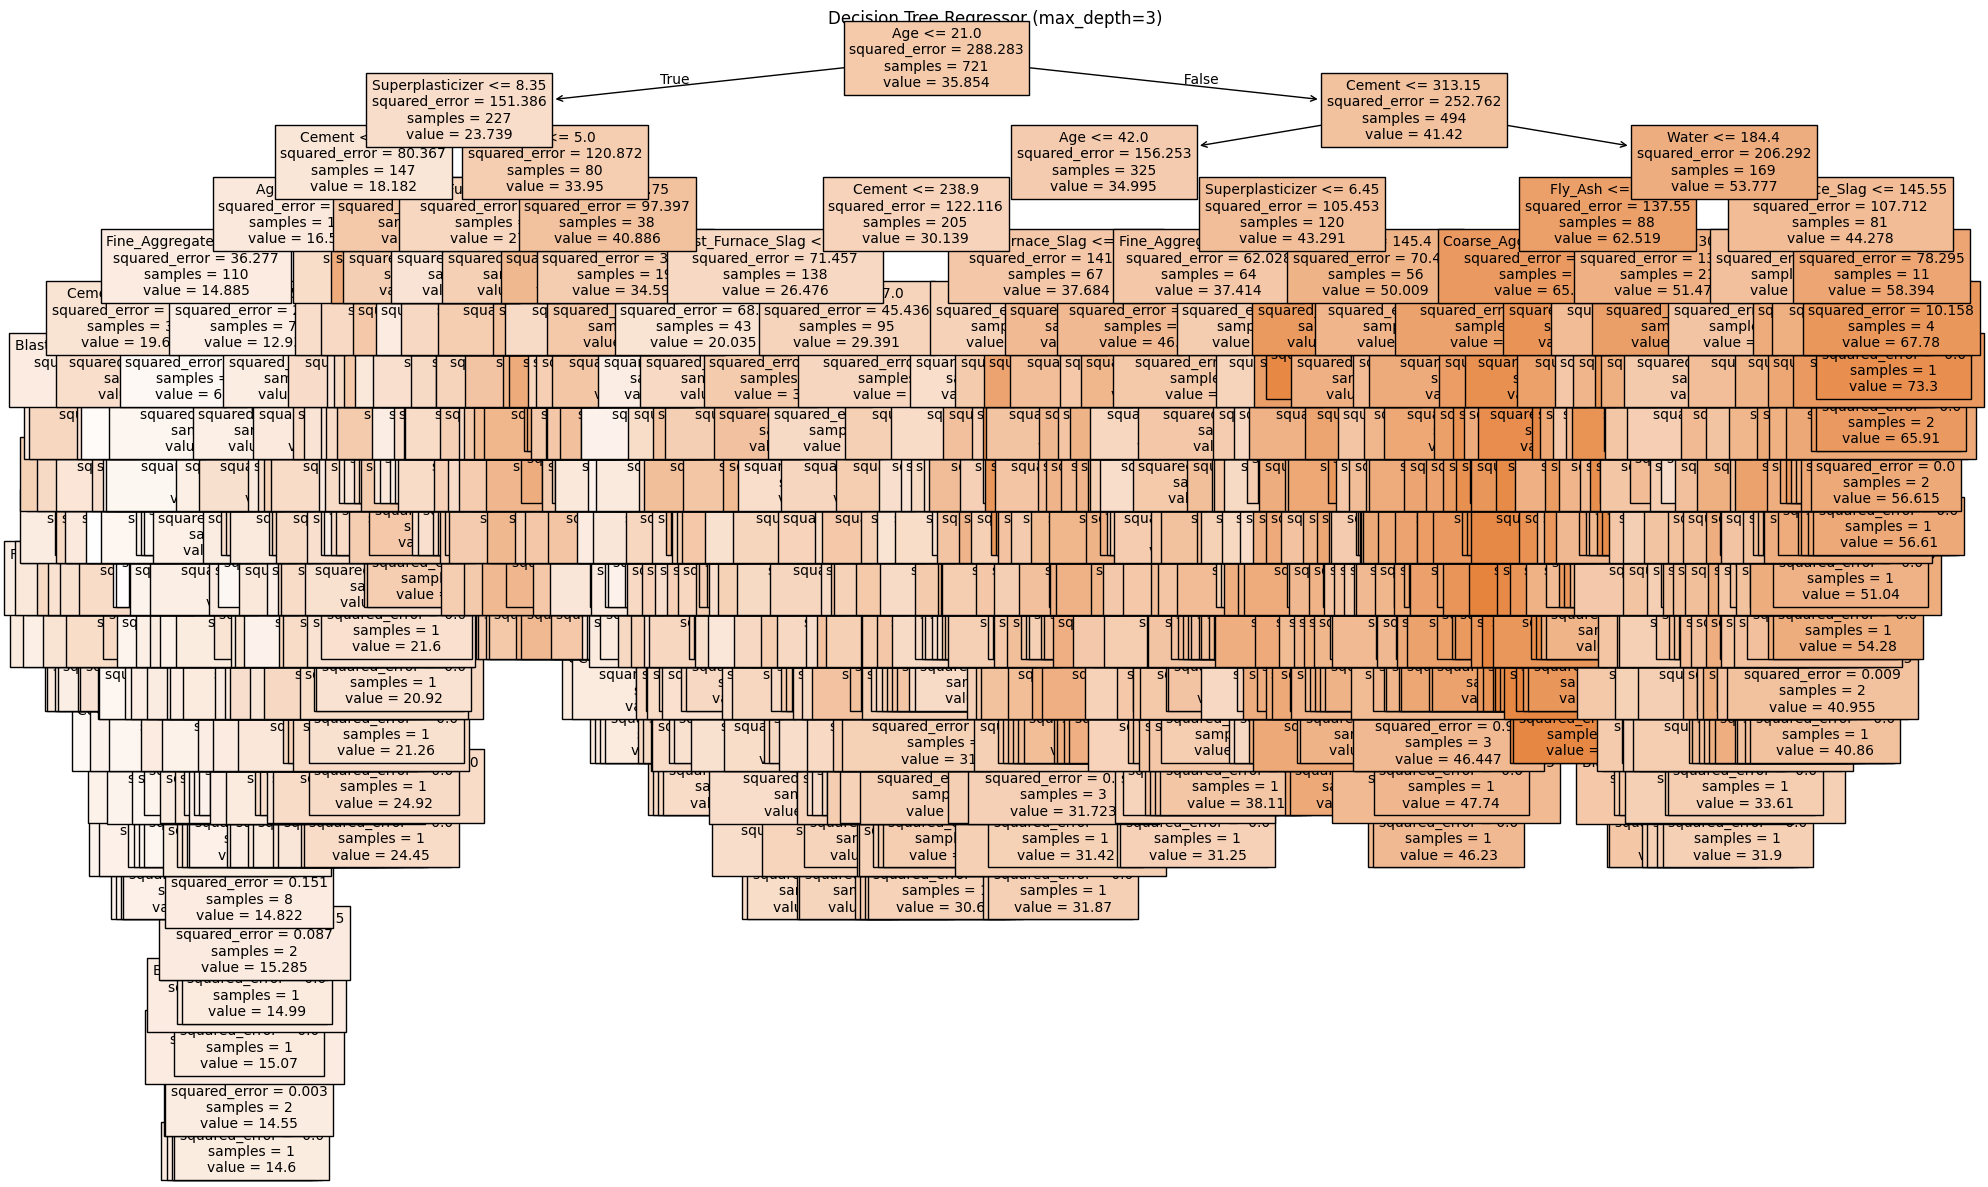

In [6]:
plt.figure(figsize=(20, 12))
tree.plot_tree(DT_reg1, filled=True, feature_names=X_reg.columns, fontsize=10)
plt.title("Decision Tree Regressor (max_depth=3)")
plt.tight_layout()
plt.show()

### 1-4) 예측 시각화

> 대각선(빨간 점선)에 가까울수록 예측이 정확함. 선형 회귀와 달리 의사결정나무는 끝 노드 개수만큼의 계단 형태 예측값을 가짐

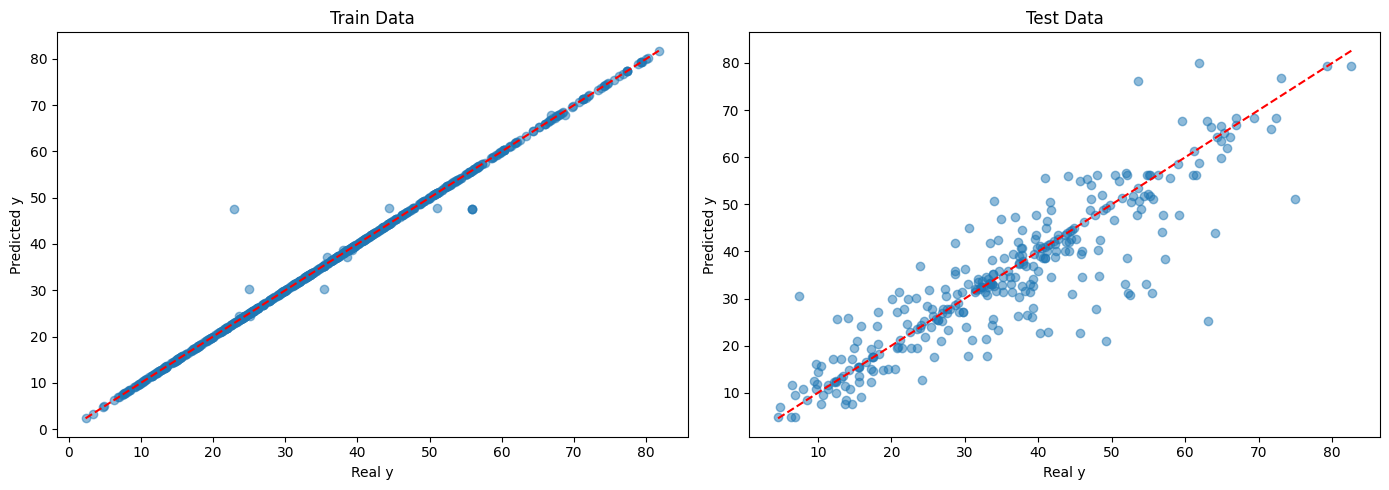

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_reg_train, DT_reg1.predict(X_reg_train), alpha=0.5)
axes[0].plot([Y_reg_train.min(), Y_reg_train.max()],
             [Y_reg_train.min(), Y_reg_train.max()], "r--")
axes[0].set_xlabel("Real y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title("Train Data")

axes[1].scatter(Y_reg_test, DT_reg1_pred, alpha=0.5)
axes[1].plot([Y_reg_test.min(), Y_reg_test.max()],
             [Y_reg_test.min(), Y_reg_test.max()], "r--")
axes[1].set_xlabel("Real y")
axes[1].set_ylabel("Predicted y")
axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 1-5) max_depth에 따른 과적합 확인

> 나무가 과하게 깊어지면(max_depth가 커지면) 학습 데이터에 **과적합**되어 테스트 데이터의 성능이 떨어질 수 있음

In [8]:
DT_reg2 = DecisionTreeRegressor(random_state=0, max_depth=10)
DT_reg2.fit(X_reg_train, Y_reg_train)
DT_reg2_pred = DT_reg2.predict(X_reg_test)

DT_reg3 = DecisionTreeRegressor(random_state=0, max_depth=5)
DT_reg3.fit(X_reg_train, Y_reg_train)
DT_reg3_pred = DT_reg3.predict(X_reg_test)

print("=== max_depth=None ===")
get_regscore(Y_reg_test, DT_reg1_pred)
print()
print("=== max_depth=10 ===")
get_regscore(Y_reg_test, DT_reg2_pred)
print()
print("=== max_depth=5 ===")
get_regscore(Y_reg_test, DT_reg3_pred)
print()
print("=== Day 2-1 다중선형회귀 참고 ===")
print("RMSE      : 9.676")
print("R-squared : 0.635")

=== max_depth=None ===
MSE       : 54.689
RMSE      : 7.395
MAE       : 4.708
R-squared : 0.787

=== max_depth=10 ===
MSE       : 56.136
RMSE      : 7.492
MAE       : 4.900
R-squared : 0.781

=== max_depth=5 ===
MSE       : 82.974
RMSE      : 9.109
MAE       : 6.894
R-squared : 0.677

=== Day 2-1 다중선형회귀 참고 ===
RMSE      : 9.676
R-squared : 0.635


---

## 2) 의사결정나무 분류 (Classification)

> 의사결정나무 **분류**에서는 **지니 불순도(Gini Impurity)** 를 기준으로 데이터를 가장 잘 구분하는 입력변수와 경계 값을 선택함
> - $Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$ (불순도가 0이면 완벽히 분류된 상태)
> - **정보 이득(Information Gain)** 이 가장 큰 변수로 노드를 분할함
> - Day 2-2에서 학습한 로지스틱 회귀와 동일한 데이터로 성능을 비교함

### 2-1) 데이터 준비

> Day 2-2에서 사용한 제조 불량 데이터를 동일하게 사용함

In [9]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-3_cls_data.csv"))

#MF_Data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/day2-3_data.csv")

# 입출력 변수 분할
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")
X = pd.get_dummies(X)
data_columns = X.columns

# 출력변수 값 변경
Y = Y.replace({"No": 0, "Yes": 1}).astype(int)

# 학습/테스트 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

print("학습 데이터 크기   :", X_train.shape, Y_train.shape)
print("테스트 데이터 크기 :", X_test.shape, Y_test.shape)

학습 데이터 크기   : (5530, 31) (5530,)
테스트 데이터 크기 : (2370, 31) (2370,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_2816\3403311988.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1}).astype(int)


In [10]:
# 분류 모형 성능 지표 산출 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % (accuracy_score(real, pred)))
    print("Precision : %.3f" % (precision_score(real, pred)))
    print("Recall    : %.3f" % (recall_score(real, pred)))
    print("F1-score  : %.3f" % (f1_score(real, pred)))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 2-2) 모델 학습

In [11]:
DT_cla1 = DecisionTreeClassifier()
DT_cla1.fit(X_train, Y_train)
DT_cla1_pred = DT_cla1.predict(X_test)
get_classscore(Y_test, DT_cla1_pred)

Accuracy  : 0.996
Precision : 0.842
Recall    : 0.727
F1-score  : 0.780

혼동행렬
[[2345    3]
 [   6   16]]


### 2-3) 나무 시각화

> 의사결정나무의 큰 장점은 모델의 **분류 규칙을 직관적으로 이해**할 수 있다는 것임

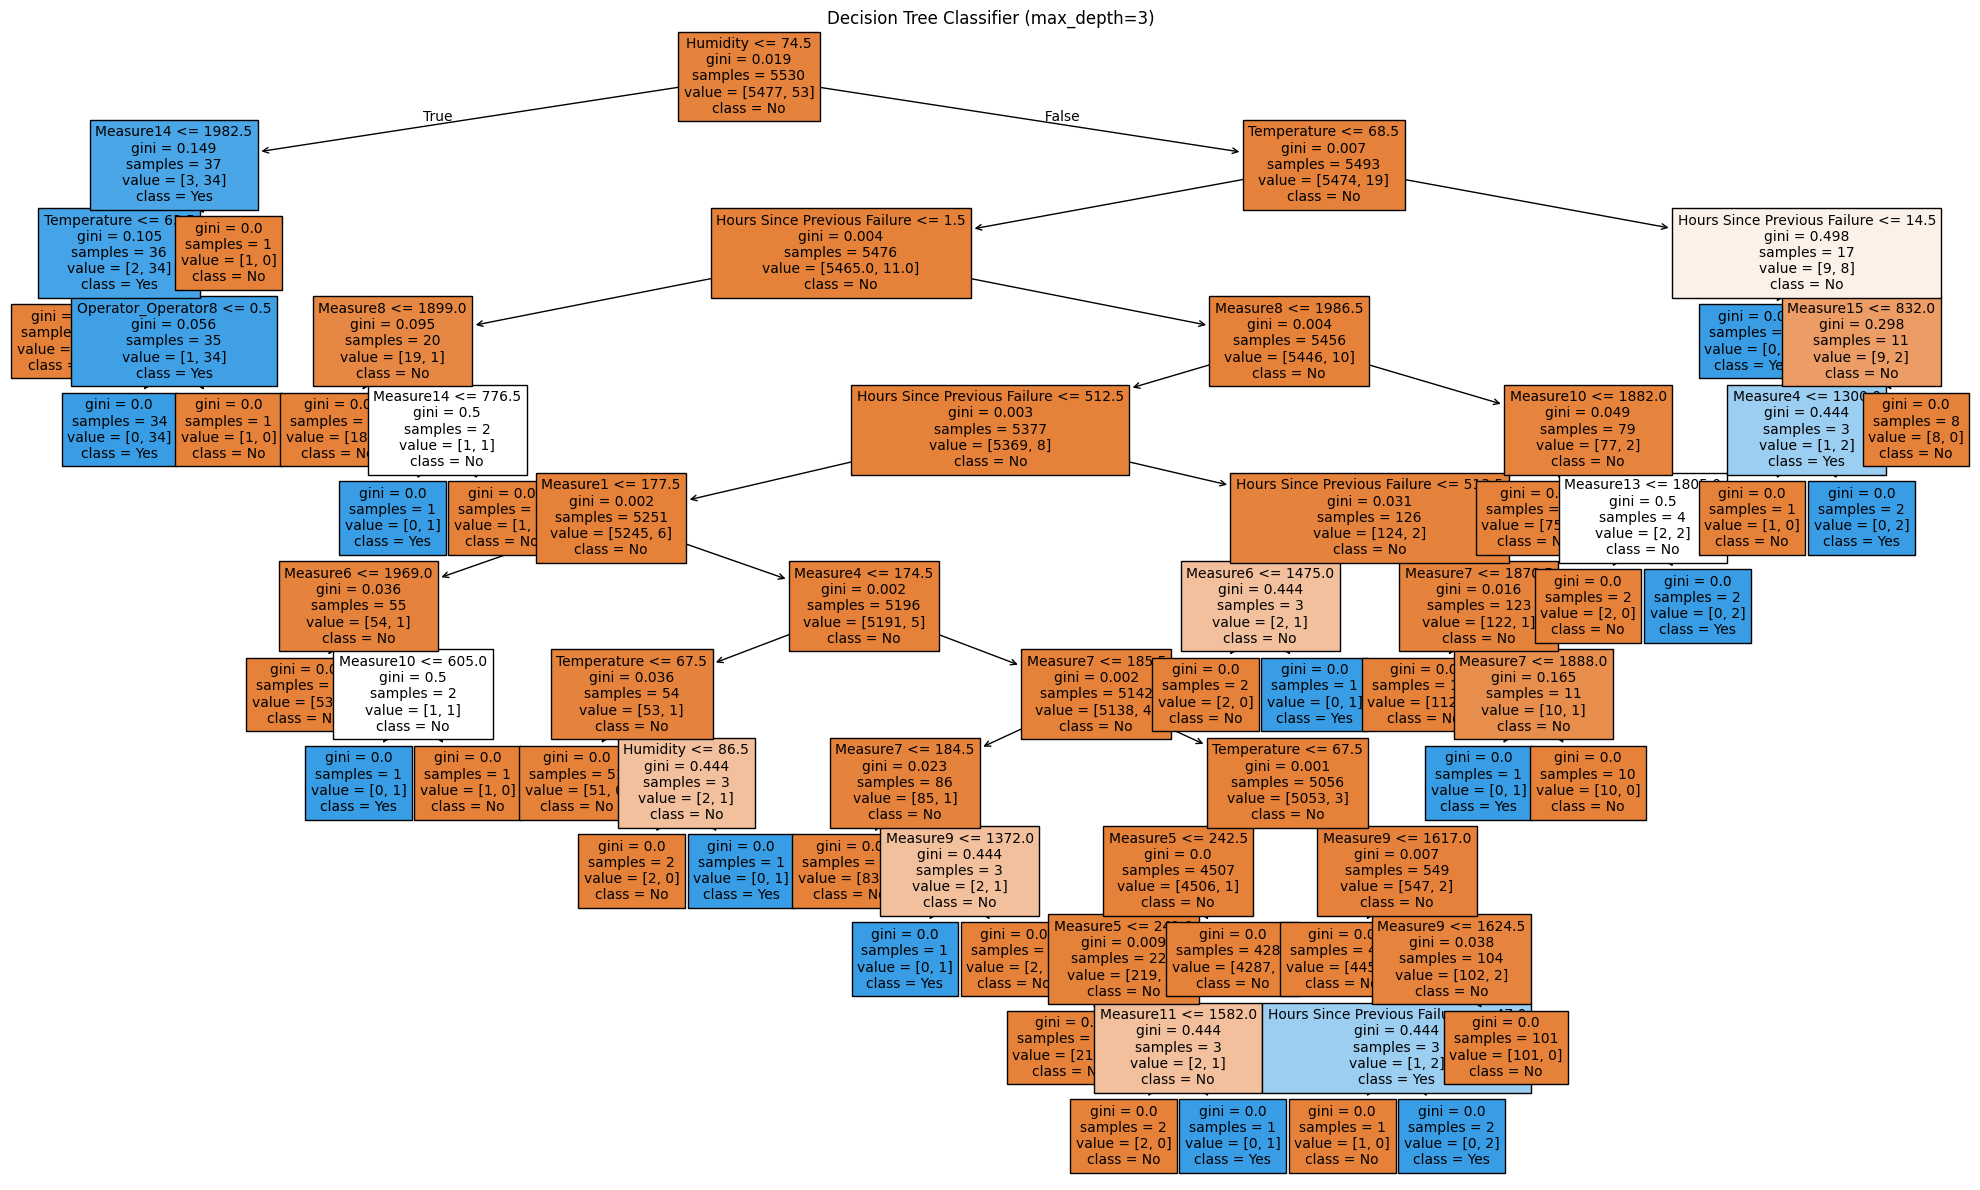

In [12]:
plt.figure(figsize=(20, 12))
tree.plot_tree(DT_cla1, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=10)
plt.title("Decision Tree Classifier (max_depth=3)")
plt.tight_layout()
plt.show()

### 2-4) max_depth에 따른 과적합 확인

> 나무가 깊어지면(max_depth가 커지면) 학습 데이터에 **과적합**되어 테스트 데이터의 성능이 떨어질 수 있음
> - **사전 가지치기**: max_depth, max_leaf_nodes, min_samples_leaf 등을 설정하여 나무 성장을 제한
> - **사후 가지치기**: 완성된 나무에서 유의미하지 않은 가지를 제거 (ccp_alpha 사용)

In [13]:
# max_depth=10으로 변경
DT_cla2 = DecisionTreeClassifier(max_depth=10)
DT_cla2.fit(X_train, Y_train)
DT_cla2_pred = DT_cla2.predict(X_test)

print("=== max_depth=None ===")
get_classscore(Y_test, DT_cla1_pred)
print()
print("=== max_depth=10 ===")
get_classscore(Y_test, DT_cla2_pred)

=== max_depth=None ===
Accuracy  : 0.996
Precision : 0.842
Recall    : 0.727
F1-score  : 0.780

혼동행렬
[[2345    3]
 [   6   16]]

=== max_depth=10 ===
Accuracy  : 0.996
Precision : 0.773
Recall    : 0.773
F1-score  : 0.773

혼동행렬
[[2343    5]
 [   5   17]]


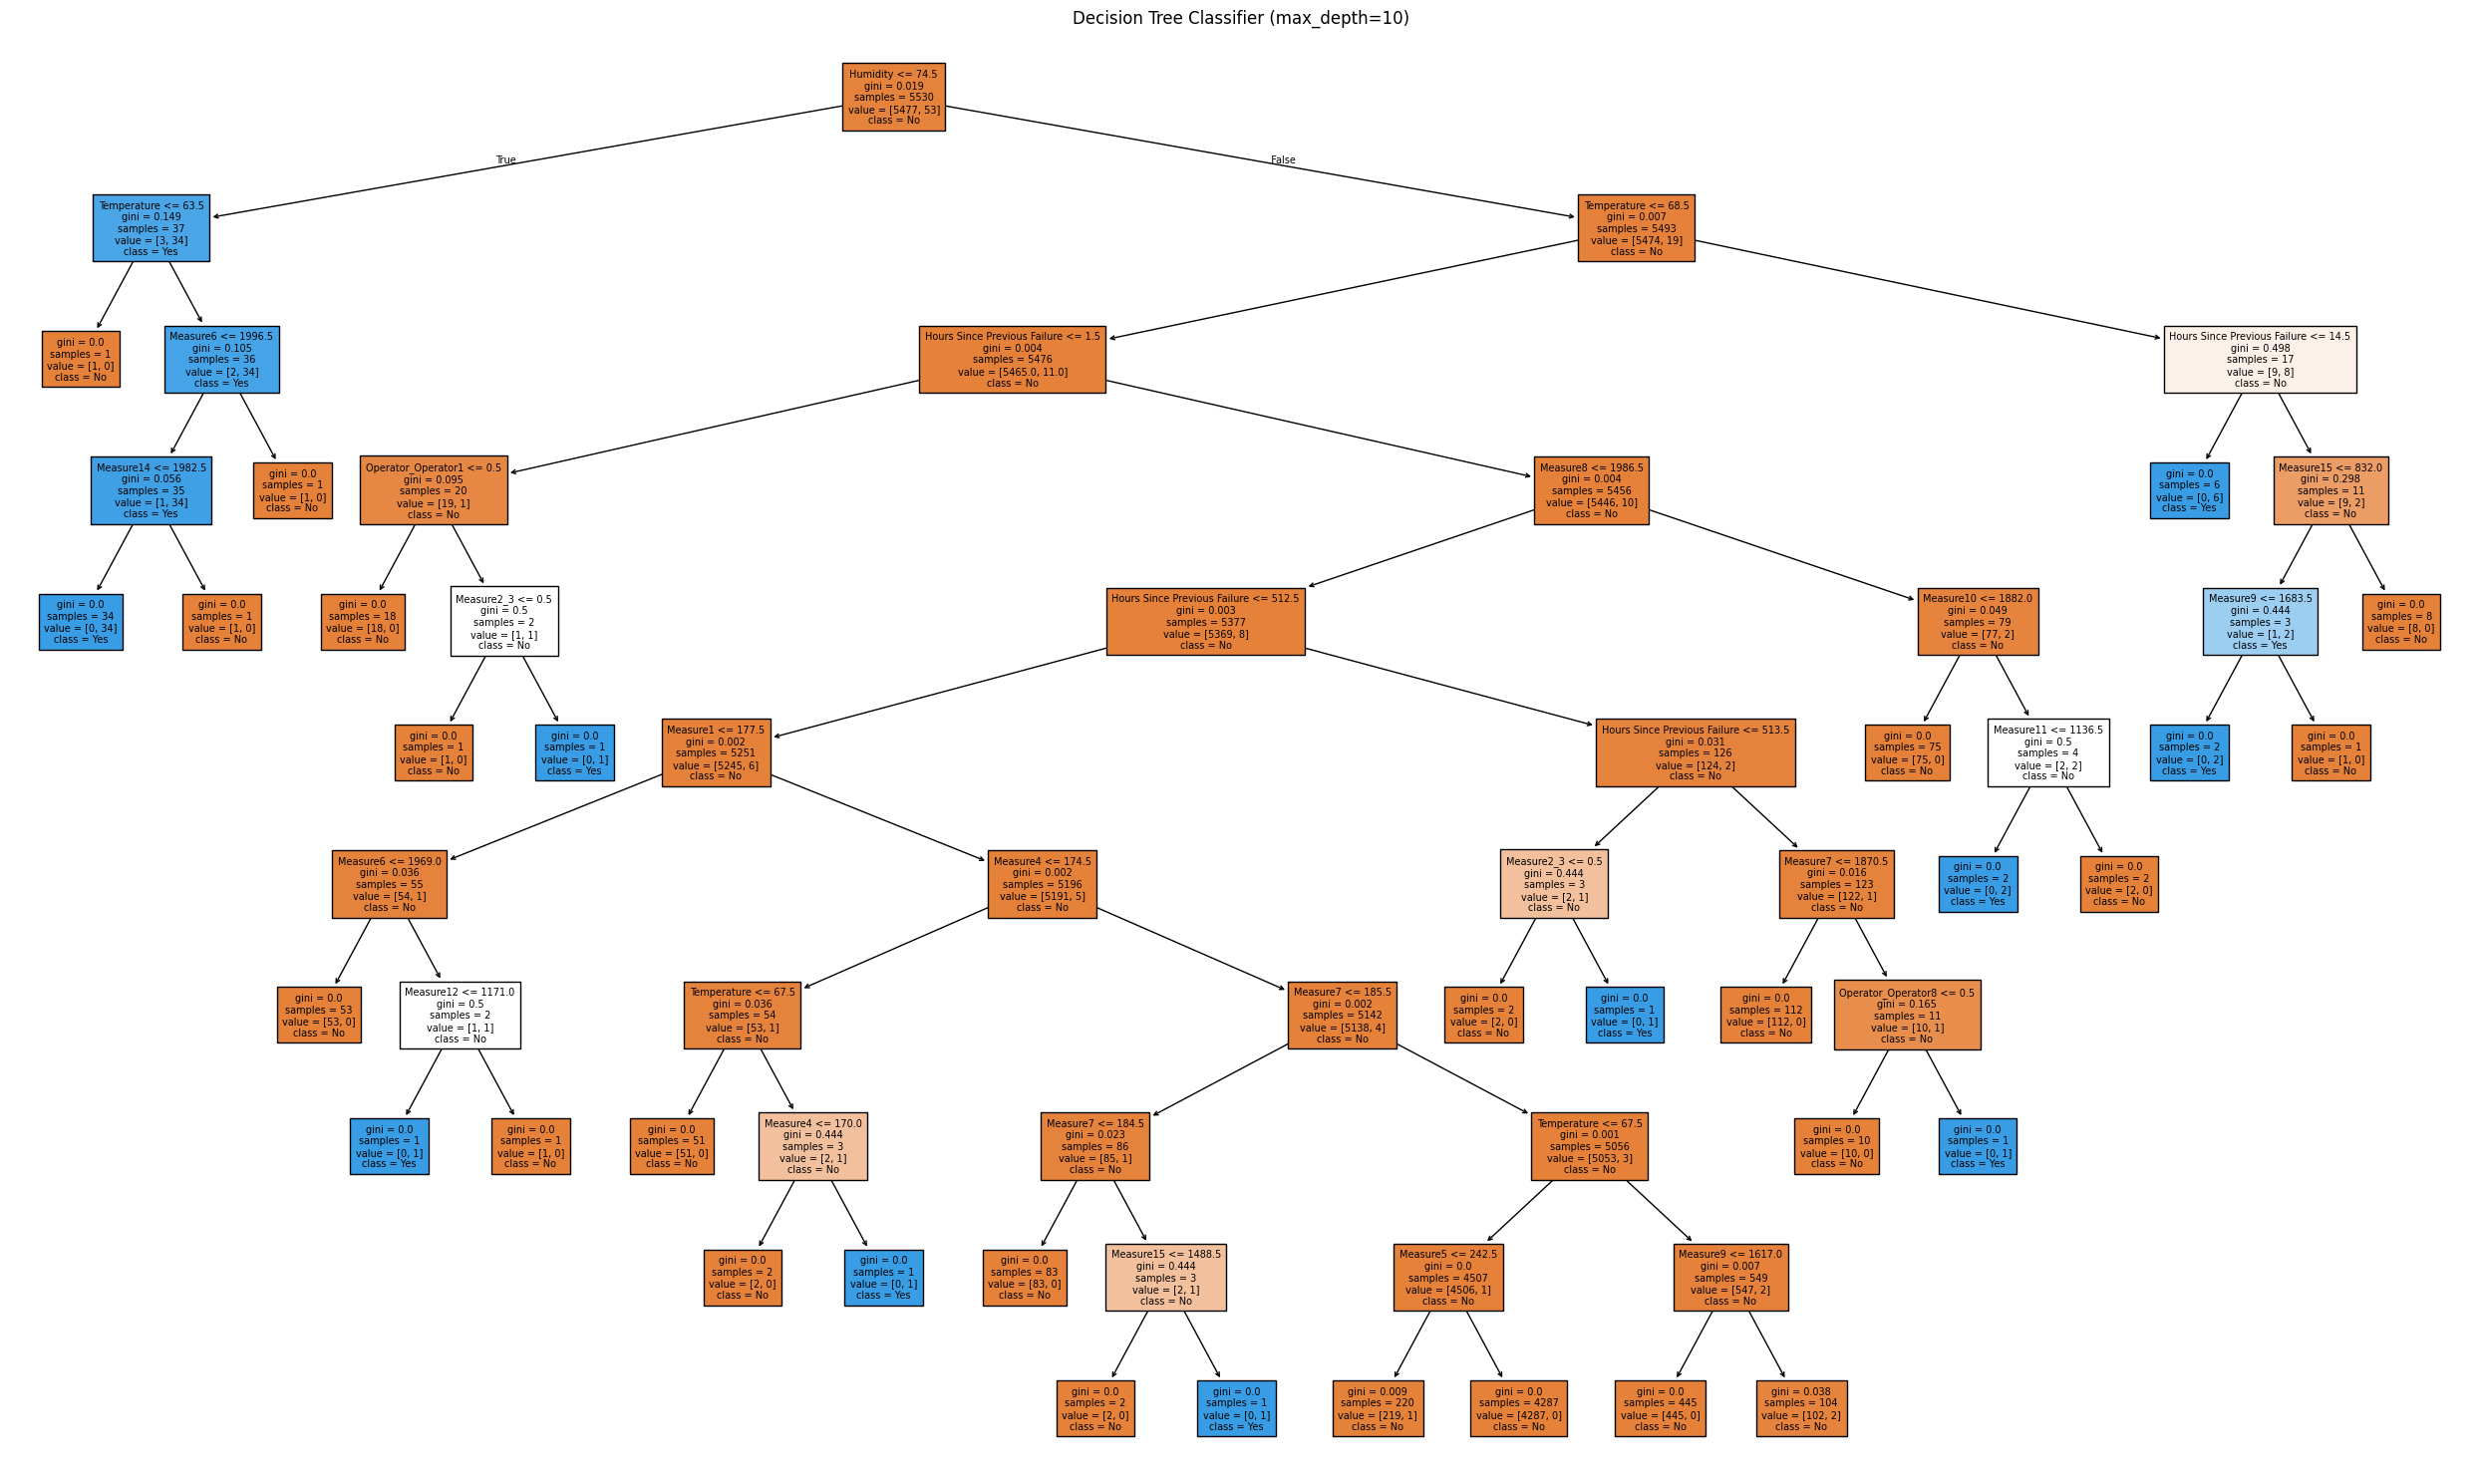

In [14]:
# 나무 시각화 (복잡한 나무)
plt.figure(figsize=(25, 15))
tree.plot_tree(DT_cla2, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=7)
plt.title("Decision Tree Classifier (max_depth=10)")
plt.tight_layout()
plt.show()

### 2-5) 가지치기를 통한 과적합 방지

> max_depth=10 모델은 과적합되어 F1 Score가 크게 떨어졌음
> - **사전 가지치기**: min_samples_leaf를 설정하여 나무 성장을 제한
> - **사후 가지치기**: ccp_alpha를 사용하여 완성된 나무에서 불필요한 가지를 제거

In [15]:
# 사전 가지치기
DT_pre = DecisionTreeClassifier(max_depth=10, min_samples_leaf=3)
DT_pre.fit(X_train, Y_train)
DT_pre_pred = DT_pre.predict(X_test)

print("=== 사전 가지치기 (max_depth=10, min_samples_leaf=5) ===")
get_classscore(Y_test, DT_pre_pred)

=== 사전 가지치기 (max_depth=10, min_samples_leaf=5) ===
Accuracy  : 0.996
Precision : 0.882
Recall    : 0.682
F1-score  : 0.769

혼동행렬
[[2346    2]
 [   7   15]]


> ccp_alpha는 비교하고자 하는 성능지표가 가장 높은 지점을 선택하며, alpha가 너무 크면 나무가 과도하게 잘려 underfitting됨

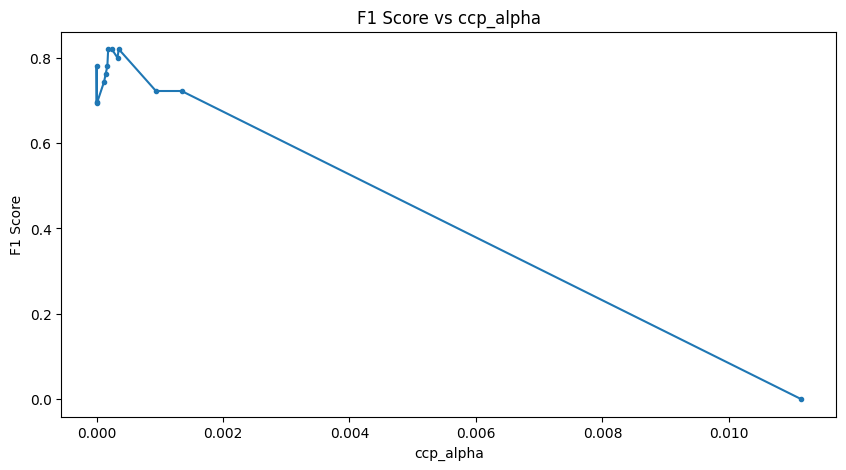

최적 ccp_alpha: 0.00018

=== 사전 가지치기  ===
Accuracy  : 0.996
Precision : 0.882
Recall    : 0.682
F1-score  : 0.769

혼동행렬
[[2346    2]
 [   7   15]]

=== 사후 가지치기 (ccp_alpha=0.00018) ===
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821

혼동행렬
[[2347    1]
 [   6   16]]


In [16]:
# 사후 가지치기: ccp_alpha별 테스트 F1 score 비교
path = DT_cla2.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas

f1_scores = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha)
    dt.fit(X_train, Y_train)
    pred = dt.predict(X_test)
    f1_scores.append(f1_score(Y_test, pred))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, f1_scores, marker="o", markersize=3)
plt.xlabel("ccp_alpha")
plt.ylabel("F1 Score")
plt.title("F1 Score vs ccp_alpha")
plt.show()

best_idx = np.argmax(f1_scores)
print("최적 ccp_alpha:", round(ccp_alphas[best_idx], 5))

# 최적 ccp_alpha로 모델 학습 및 성능 비교
best_alpha = ccp_alphas[best_idx]
DT_post = DecisionTreeClassifier(ccp_alpha=best_alpha)
DT_post.fit(X_train, Y_train)
DT_post_pred = DT_post.predict(X_test)

print("\n=== 사전 가지치기  ===")
get_classscore(Y_test, DT_pre_pred)
print()
print(f"=== 사후 가지치기 (ccp_alpha={best_alpha:.5f}) ===")
get_classscore(Y_test, DT_post_pred)

---

## 3) 하이퍼 파라미터 최적화

> 의사결정나무의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | max_depth | 트리의 최대 깊이 |
> | max_leaf_nodes | 끝 노드(Leaf)의 최대 개수 |
> | min_samples_leaf | 끝 노드가 되기 위한 최소 샘플 수 |
> | min_samples_split | 노드를 분할하기 위한 최소 샘플 수 |
> | ccp_alpha | 사후 가지치기 강도 (값이 클수록 가지를 많이 제거) |

### 3-1) Grid Search

> **Grid Search**는 하이퍼 파라미터의 모든 조합을 탐색하여 최적의 조합을 찾는 방법임

In [17]:
from sklearn.model_selection import ParameterGrid

# 하이퍼파라미터 그리드 설정
params = {
    "max_depth": range(1, 20, 5),
    "min_samples_leaf": [6, 8, 10],
    "min_samples_split": [6, 8, 10],
    "ccp_alpha": [0, 0.001, 0.005, 0.01]
}

param_grid = list(ParameterGrid(params))
score_list = []

for param in param_grid:
    dt = DecisionTreeClassifier(**param)
    dt.fit(X_train, Y_train)
    y_pred = dt.predict(X_test)
    score = f1_score(Y_test, y_pred)
    score_list.append(score)

print("최적의 하이퍼파라미터:", param_grid[np.argmax(score_list)])
print("최적의 성능 (F1 score):", np.round(np.max(score_list), 4))

최적의 하이퍼파라미터: {'ccp_alpha': 0, 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 6}
최적의 성능 (F1 score): 0.8293


### 3-2) 최적 모델 학습

In [18]:
# 최적 하이퍼파라미터로 모델 재학습
best_params = param_grid[np.argmax(score_list)]

DT_best = DecisionTreeClassifier(**best_params)
DT_best.fit(X_train, Y_train)
DT_best_predict = DT_best.predict(X_test)
get_classscore(Y_test, DT_best_predict)

Accuracy  : 0.997
Precision : 0.895
Recall    : 0.773
F1-score  : 0.829

혼동행렬
[[2346    2]
 [   5   17]]


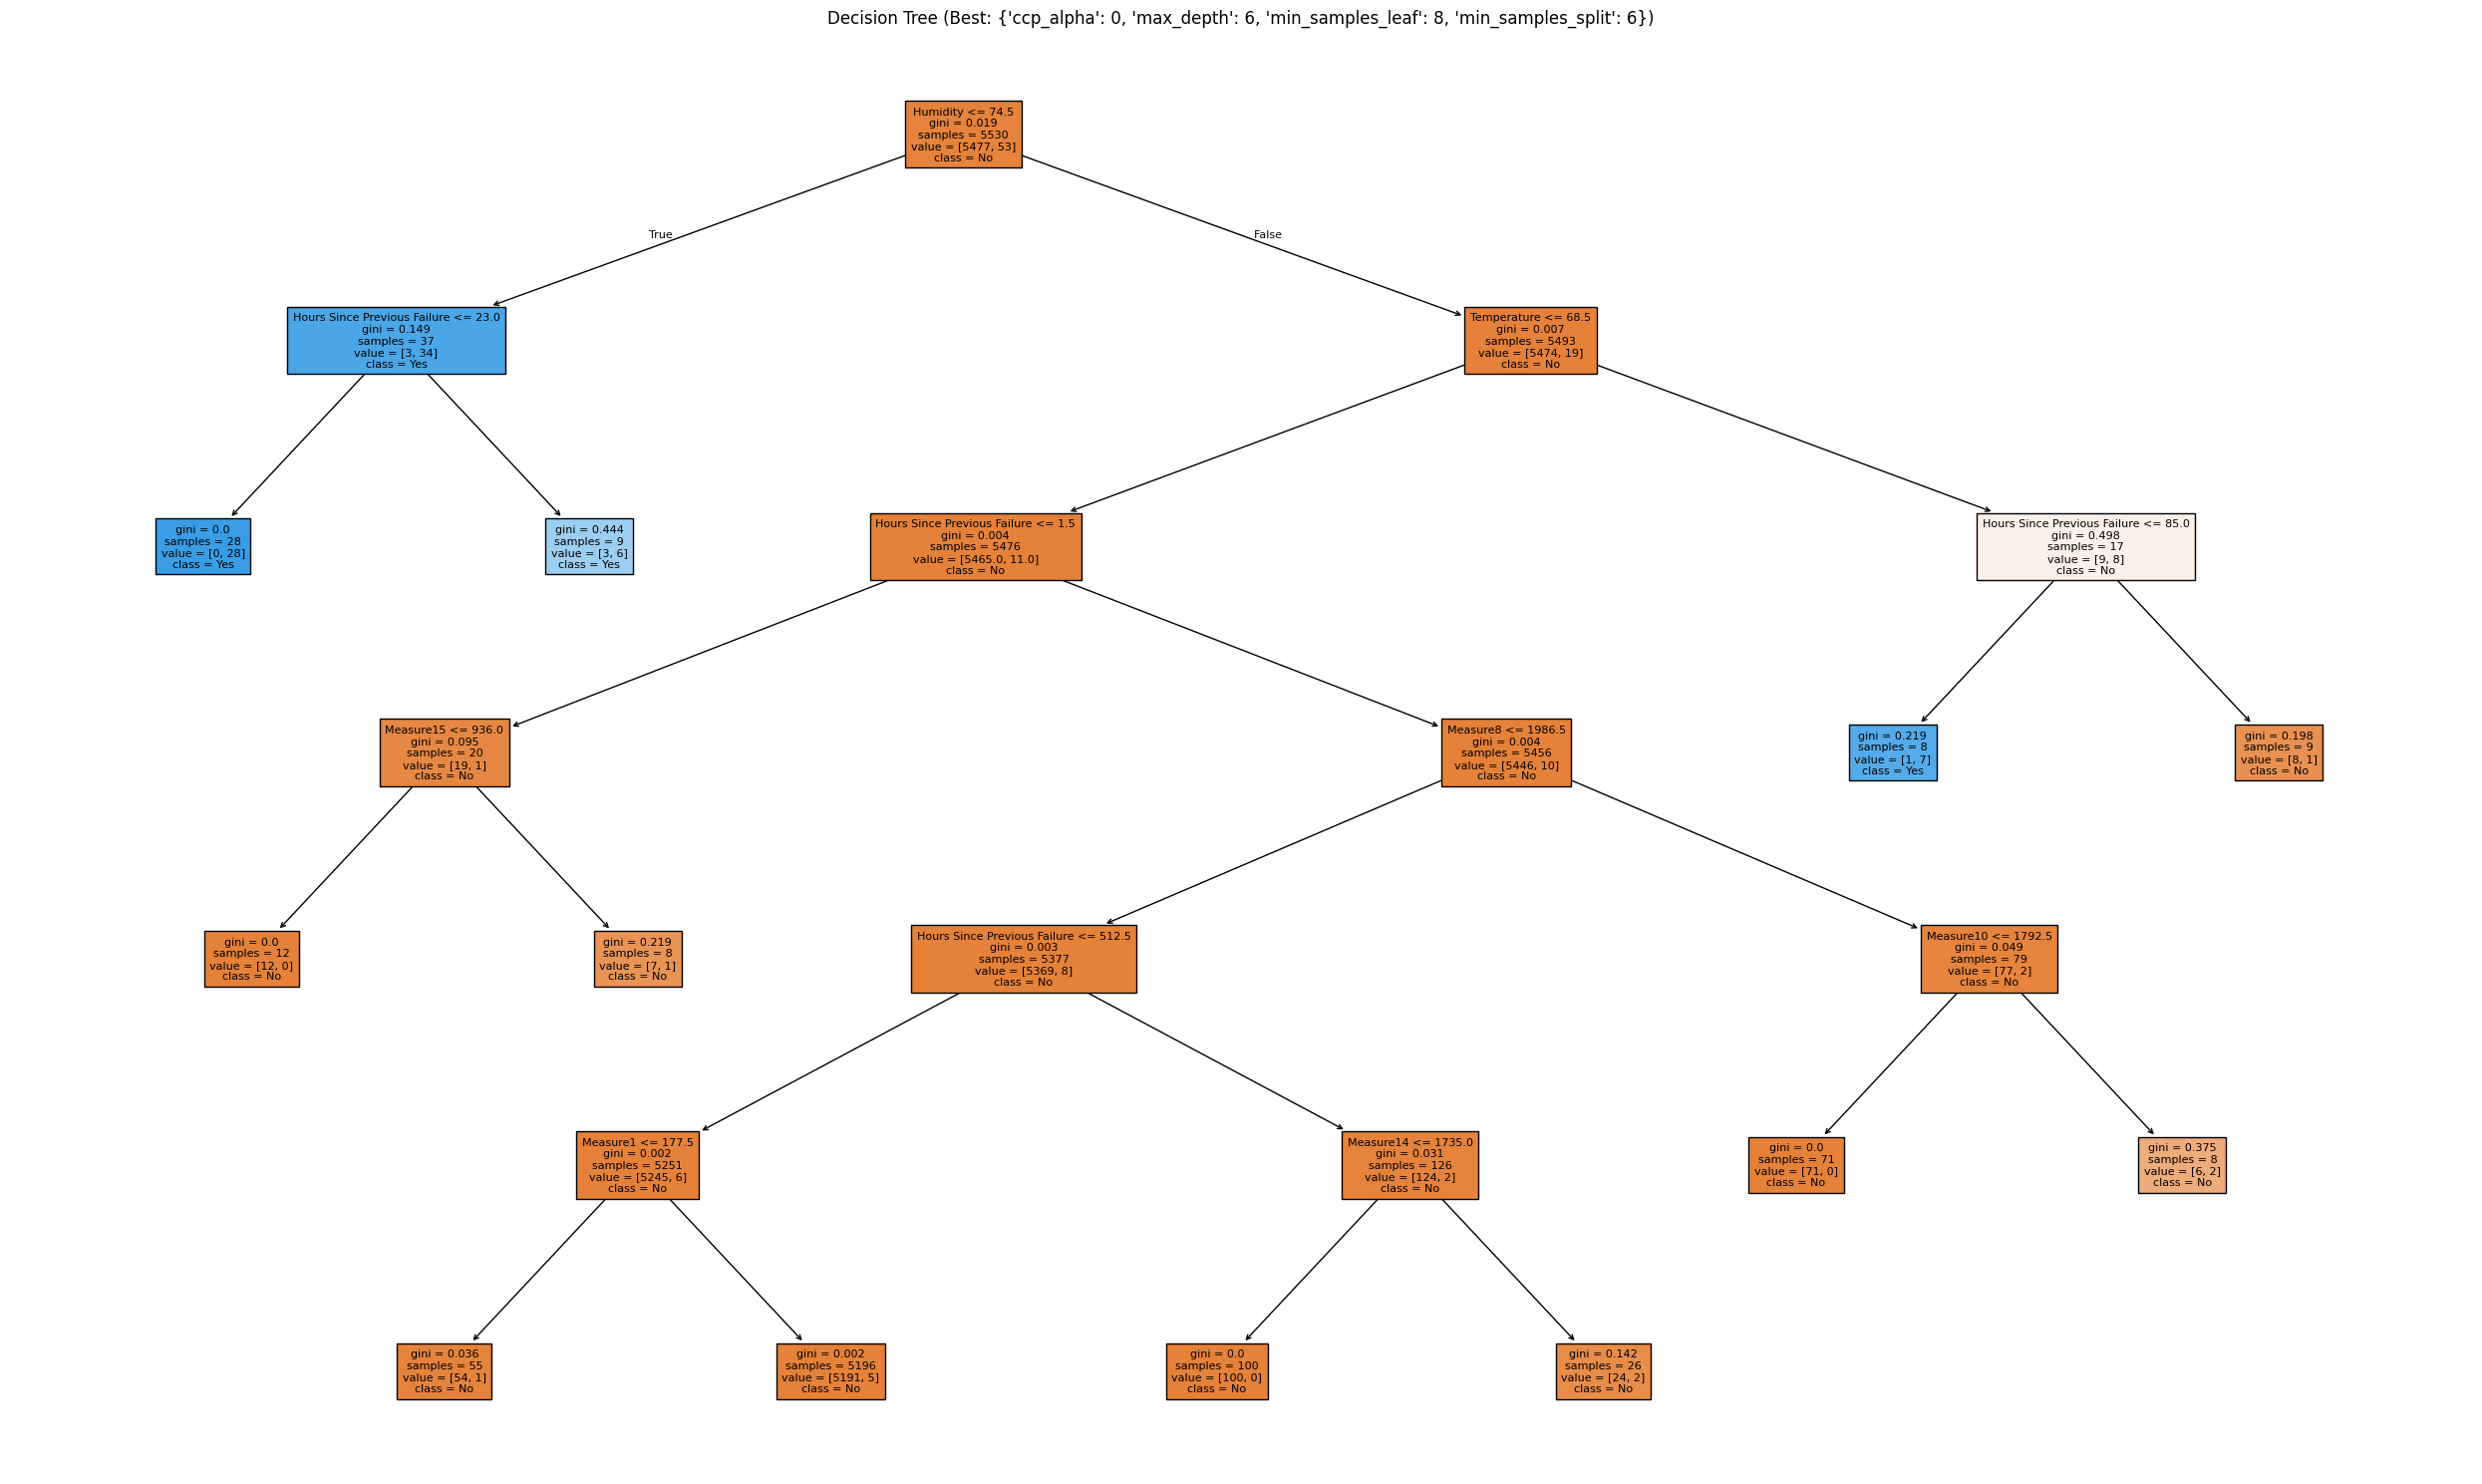

In [19]:
# 최적 모델 나무 시각화
plt.figure(figsize=(25, 15))
tree.plot_tree(DT_best, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=8)
plt.title(f"Decision Tree (Best: {best_params})")
plt.tight_layout()
plt.show()

---

## 4) Vibe Coding 실습

### 4-1) 회귀 / 분류 나무 심화

**[과제 1]** 지수는 회귀 나무 모델의 깊이가 너무 깊어지면 과적합이 발생할 수 있다는 점을 알게 되었습니다. AI와 함께 적절한 트리 깊이를 찾는 방법을 알아보고, 다양한 깊이에서의 성능을 비교하여 가장 적절한 깊이를 찾아보세요.

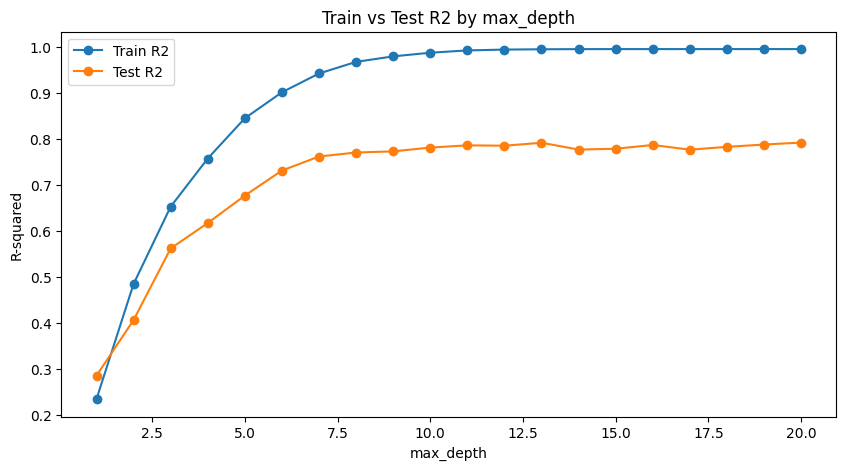

Test R2가 가장 높은 max_depth: 20 (Test R2 = 0.792)

=== 최적 max_depth = 20 ===
MSE       : 53.344
RMSE      : 7.304
MAE       : 4.707
R-squared : 0.792


In [20]:
# [과제1] 회귀 나무의 적절한 max_depth 찾기

depth_list = range(1, 21)
train_scores = []
test_scores = []

for depth in depth_list:
    dt = DecisionTreeRegressor(random_state=0, max_depth=depth)
    dt.fit(X_reg_train, Y_reg_train)

    train_r2 = r2_score(Y_reg_train, dt.predict(X_reg_train))
    test_r2 = r2_score(Y_reg_test, dt.predict(X_reg_test))

    train_scores.append(train_r2)
    test_scores.append(test_r2)

# 학습/테스트 성능을 함께 시각화 -> 두 곡선이 벌어지는 지점이 과적합 시작 지점
plt.figure(figsize=(10, 5))
plt.plot(depth_list, train_scores, marker="o", label="Train R2")
plt.plot(depth_list, test_scores, marker="o", label="Test R2")
plt.xlabel("max_depth")
plt.ylabel("R-squared")
plt.title("Train vs Test R2 by max_depth")
plt.legend()
plt.show()

# 테스트 성능이 가장 좋은 depth 선택
best_depth = list(depth_list)[np.argmax(test_scores)]
print("Test R2가 가장 높은 max_depth:", best_depth, "(Test R2 = %.3f)" % max(test_scores))

# 해석: depth가 커질수록 Train R2는 계속 1에 가까워지지만(과적합 진행),
#       Test R2는 어느 시점(약 depth=8~13) 이후로는 더 이상 좋아지지 않고 정체됨
#       -> 성능은 비슷하면서 더 단순한(과적합 위험이 적은) depth를 선택하는 것이 바람직함
DT_reg_best = DecisionTreeRegressor(random_state=0, max_depth=best_depth)
DT_reg_best.fit(X_reg_train, Y_reg_train)
DT_reg_best_pred = DT_reg_best.predict(X_reg_test)

print("\n=== 최적 max_depth =", best_depth, "===")
get_regscore(Y_reg_test, DT_reg_best_pred)


### 4-2) 모델 결과 해석 심화

**[과제 2]** 지수는 회귀 나무와 분류 나무가 어떤 변수를 중요하게 사용하여 데이터를 분할하는지 궁금해졌습니다. AI와 함께 각 모델의 주요 변수를 확인하고, 해당 변수가 중요한 이유를 분할 기준 및 변수명과 함께 해석해 보세요. 또한 트리 구조를 살펴보며 데이터의 특성을 설명할 수 있는 의사결정 규칙을 직접 도출해 보세요.

In [ ]:
# [과제2] 변수 중요도 확인 및 의사결정 규칙 도출

# 1) 회귀 나무 변수 중요도 (feature_importances_ 사용)
reg_importance = pd.Series(DT_reg_best.feature_importances_, index=X_reg.columns)
reg_importance = reg_importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=reg_importance.values, y=reg_importance.index)
plt.title("Regression Tree - Feature Importance")
plt.xlabel("Importance")
plt.show()

print("[Regression] 변수 중요도 순위:")
print(reg_importance)

# 2) 분류 나무 변수 중요도
cla_importance = pd.Series(DT_cla1.feature_importances_, index=data_columns)
cla_importance = cla_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cla_importance.head(10).values, y=cla_importance.head(10).index)
plt.title("Classification Tree - Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

print("\n[Classification] 변수 중요도 Top 10:")
print(cla_importance.head(10))

# 3) 의사결정 규칙을 텍스트로 출력 (tree.export_text)
print("\n=== 회귀 나무 의사결정 규칙 (상위 3 depth) ===")
print(tree.export_text(DT_reg_best, feature_names=list(X_reg.columns), max_depth=3))

print("\n=== 분류 나무 의사결정 규칙 (상위 3 depth) ===")
print(tree.export_text(DT_cla1, feature_names=list(data_columns), max_depth=3))

# 해석 예시:
# - 회귀: 중요도가 높은 변수(예: Age, Cement 등)가 루트 노드 근처에서 먼저 분할됨
#   -> 해당 변수가 콘크리트 압축강도 예측에 가장 큰 영향을 미침
# - 분류: 중요도가 높은 변수(예: Measure1, Measure2 등)가 불량 여부를 가르는 핵심 기준
#   -> export_text 결과에서 "feature <= 값" 형태로 실제 분할 기준을 직접 확인 가능


### 4-3) 모델 고도화 심화

**[과제 3]** 지수는 의사결정나무 모델의 하이퍼파라미터가 많아 어떤 값을 기준으로 탐색해야 할지 고민하고 있습니다. AI와 함께 주요 하이퍼파라미터의 의미를 알아보고, 회귀 나무와 분류 나무에 적절한 탐색 범위를 설정해 보세요. 이후 적절한 하이퍼파라미터 튜닝 기법을 적용하여 모델 성능이 얼마나 개선되는지 확인해 보세요.

In [27]:
# [과제3] 의사결정나무 하이퍼파라미터 튜닝 (GridSearchCV)
from sklearn.model_selection import GridSearchCV

# 탐색 범위(실습용): 핵심 파라미터 위주로 설정
# - max_depth: 트리 깊이 제한 (과적합 방지)
# - min_samples_leaf: 리프 노드 최소 샘플 수
# - min_samples_split: 분할을 위한 최소 샘플 수
# - ccp_alpha: 사후 가지치기 강도
reg_param_grid = {
    "max_depth": [4, 6, 8, 10, 12],
    "min_samples_leaf": [2, 4, 6],
    "min_samples_split": [4, 8, 12],
}

cla_param_grid = {
    "max_depth": [4, 6, 8, 10, 12],
    "min_samples_leaf": [2, 4, 6],
    "min_samples_split": [4, 8, 12],
    "ccp_alpha": [0.0, 0.001, 0.005],
}

# 1) 회귀 트리 튜닝 (scoring = R2)
grid_reg = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=0),
    param_grid=reg_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
)
grid_reg.fit(X_reg_train, Y_reg_train)

best_reg_tuned = grid_reg.best_estimator_
best_reg_tuned_pred = best_reg_tuned.predict(X_reg_test)

print("[Regression] 최적 파라미터:", grid_reg.best_params_)
print("[Regression] CV 최고 R2:", round(grid_reg.best_score_, 4))
print("[Regression] 튜닝 후 Test R2:", round(r2_score(Y_reg_test, best_reg_tuned_pred), 4))

# 2) 분류 트리 튜닝 (scoring = F1)
grid_cla = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=cla_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
)
grid_cla.fit(X_train, Y_train)

best_cla_tuned = grid_cla.best_estimator_
best_cla_tuned_pred = best_cla_tuned.predict(X_test)

print("[Classification] 최적 파라미터:", grid_cla.best_params_)
print("[Classification] CV 최고 F1:", round(grid_cla.best_score_, 4))
print("[Classification] 튜닝 후 Test F1:", round(f1_score(Y_test, best_cla_tuned_pred), 4))

# 기존 모델 대비 비교
baseline_reg_r2 = r2_score(Y_reg_test, DT_reg_best_pred)
baseline_cla_f1 = f1_score(Y_test, DT_cla1_pred)

print("=== 성능 비교 ===")
print(f"회귀  : baseline R2={baseline_reg_r2:.4f} -> tuned R2={r2_score(Y_reg_test, best_reg_tuned_pred):.4f}")
print(f"분류  : baseline F1={baseline_cla_f1:.4f} -> tuned F1={f1_score(Y_test, best_cla_tuned_pred):.4f}")


[Regression] 최적 파라미터: {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 4}
[Regression] CV 최고 R2: 0.7838
[Regression] 튜닝 후 Test R2: 0.7948
[Classification] 최적 파라미터: {'ccp_alpha': 0.0, 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 4}
[Classification] CV 최고 F1: 0.7835
[Classification] 튜닝 후 Test F1: 0.7895
=== 성능 비교 ===
회귀  : baseline R2=0.7922 -> tuned R2=0.7948
분류  : baseline F1=0.7805 -> tuned F1=0.7895


### 4-4) 모델 종합 비교

**[과제 4]** 지수는 오늘 회귀 및 분류 데이터셋에 대해 여러 머신러닝 모델을 구축했지만 어떤 모델을 최종적으로 선택해야 할지 고민하고 있습니다. AI와 함께 다른 실습에서 사용한 모델들의 성능을 가져와 비교해 보고, 어떤 기준으로 모델을 선택해야 하는지 고민해 보세요. 또한 가장 우수한 성능을 보인 모델은 무엇인지, 그리고 왜 해당 모델이 좋은 성능을 보였을지 데이터의 특성과 함께 해석해 보세요.

In [28]:
# [과제4] 모델 종합 비교 (회귀/분류)
from sklearn.linear_model import LinearRegression, LogisticRegression

# 1) 회귀 모델 성능 비교 (기준 지표: R2, 보조 지표: RMSE)
LR_reg = LinearRegression()
LR_reg.fit(X_reg_train, Y_reg_train)
LR_reg_pred = LR_reg.predict(X_reg_test)

reg_compare = pd.DataFrame([
    {
        "Model": "LinearRegression (Day2-1)",
        "R2": r2_score(Y_reg_test, LR_reg_pred),
        "RMSE": np.sqrt(mean_squared_error(Y_reg_test, LR_reg_pred)),
    },
    {
        "Model": "DecisionTree baseline",
        "R2": r2_score(Y_reg_test, DT_reg_best_pred),
        "RMSE": np.sqrt(mean_squared_error(Y_reg_test, DT_reg_best_pred)),
    },
    {
        "Model": "DecisionTree tuned",
        "R2": r2_score(Y_reg_test, best_reg_tuned_pred),
        "RMSE": np.sqrt(mean_squared_error(Y_reg_test, best_reg_tuned_pred)),
    },
]).sort_values("R2", ascending=False)

print("[Regression] 모델 성능 비교")
print(reg_compare.round(4))

# 2) 분류 모델 성능 비교 (기준 지표: F1)
LR_cla = LogisticRegression(max_iter=1000)
LR_cla.fit(X_train, Y_train)
LR_cla_pred = LR_cla.predict(X_test)

cla_compare = pd.DataFrame([
    {
        "Model": "LogisticRegression (Day2-2)",
        "Accuracy": accuracy_score(Y_test, LR_cla_pred),
        "F1": f1_score(Y_test, LR_cla_pred),
        "Recall": recall_score(Y_test, LR_cla_pred),
        "Precision": precision_score(Y_test, LR_cla_pred),
    },
    {
        "Model": "DecisionTree baseline",
        "Accuracy": accuracy_score(Y_test, DT_cla1_pred),
        "F1": f1_score(Y_test, DT_cla1_pred),
        "Recall": recall_score(Y_test, DT_cla1_pred),
        "Precision": precision_score(Y_test, DT_cla1_pred),
    },
    {
        "Model": "DecisionTree tuned",
        "Accuracy": accuracy_score(Y_test, best_cla_tuned_pred),
        "F1": f1_score(Y_test, best_cla_tuned_pred),
        "Recall": recall_score(Y_test, best_cla_tuned_pred),
        "Precision": precision_score(Y_test, best_cla_tuned_pred),
    },
]).sort_values("F1", ascending=False)

print("\n[Classification] 모델 성능 비교")
print(cla_compare.round(4))

# 3) 최종 모델 선택
best_reg_name = reg_compare.iloc[0]["Model"]
best_cla_name = cla_compare.iloc[0]["Model"]

print("\n=== 최종 선택 ===")
print("회귀 최종 모델:", best_reg_name)
print("분류 최종 모델:", best_cla_name)

# 4) 해석
print("\n=== 해석 ===")
print("회귀: R2 기준으로 DecisionTree 계열이 LinearRegression보다 높음")
print("     -> 변수와 타겟 관계가 직선이 아닌 구간/임계값 기반 패턴일 가능성")
print("분류: F1 기준 최종 모델은 LogisticRegression (Accuracy만 보면 오판 가능)")
print("     -> Recall/Precision 균형을 보면서 F1로 최종 선택하는 것이 적절")


[Regression] 모델 성능 비교
                       Model      R2    RMSE
2         DecisionTree tuned  0.7948  7.2575
1      DecisionTree baseline  0.7922  7.3037
0  LinearRegression (Day2-1)  0.6353  9.6757

[Classification] 모델 성능 비교
                         Model  Accuracy      F1  Recall  Precision
0  LogisticRegression (Day2-2)    0.9970  0.8108  0.6818     1.0000
2           DecisionTree tuned    0.9966  0.7895  0.6818     0.9375
1        DecisionTree baseline    0.9962  0.7805  0.7273     0.8421

=== 최종 선택 ===
회귀 최종 모델: DecisionTree tuned
분류 최종 모델: LogisticRegression (Day2-2)

=== 해석 ===
회귀: R2 기준으로 DecisionTree 계열이 LinearRegression보다 높음
     -> 변수와 타겟 관계가 직선이 아닌 구간/임계값 기반 패턴일 가능성
분류: F1 기준 최종 모델은 LogisticRegression (Accuracy만 보면 오판 가능)
     -> Recall/Precision 균형을 보면서 F1로 최종 선택하는 것이 적절
